# PicoCal — Detector regions

The mentor suggested studying a single detector region, identified from the number of cells in the seed cell's module. This notebook explains what a region is and shows the regions in the real data. The training plan that uses these findings is in notebook 04.

## What a detector region is

The ECAL face is split into concentric **regions**. Near the beam the showers are dense, so cells are small and fine; further out cells are larger and coarser. Each region uses one cell size (pitch).

```mermaid
flowchart TB
  subgraph R4["Region 4 - 120 mm cells - outermost, few large cells"]
    subgraph R3["Region 3 - 60 mm cells"]
      subgraph R2["Region 2 - 40 mm cells"]
        subgraph R1["Region 1 - 30 mm cells"]
          R0["Region 0 - 15 mm cells - innermost, many small cells"]
        end
      end
    end
  end
```


## A module block and its cells

A **module** is a physical block of fixed size. Inside one block the region decides how finely it is divided: an inner region cuts the block into many small cells, an outer region into a few large cells. So counting the cells that belong to a module identifies its region - which is the same partition as the cell pitch (cell size).

```mermaid
flowchart LR
  M["One physical module block (fixed size)"] --> A["Inner region: many small cells (e.g. 15 mm)"]
  M --> B["Outer region: few large cells (e.g. 120 mm)"]
  A --> C["Region = high cell count per module"]
  B --> D["Region = low cell count per module"]
```


## Setup

In [1]:
from pathlib import Path
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "font.size": 12})

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
root_files = sorted((repo / "data" / "full").glob("matched_*.root"))
TREE_NAME = "clusters_matched"
PITCH = np.array([15.0, 30.0, 40.0, 60.0, 120.0])
N_SURVEY_FILES = len(root_files)
SURVEY_STEPS = [20, 40, 60, 80, 100]
VERTEX_Z_MAX = 100.0

{"n_files_total": len(root_files), "survey_files": N_SURVEY_FILES, "pitches_mm": PITCH.tolist()}

{'n_files_total': 100,
 'survey_files': 100,
 'pitches_mm': [15.0, 30.0, 40.0, 60.0, 120.0]}

## Seed region from the data

For each cluster the seed is the most energetic cell. Its region is read from the spacing of cells in the seed's own module, then matched to the nearest known pitch.

In [2]:
def seed_region(x, y, e, ix, iy):
    s = int(np.argmax(e))
    sel = (ix == ix[s]) & (iy == iy[s])
    pts = np.stack([x[sel], y[sel]], 1)
    if len(pts) >= 2:
        d = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(-1))
        d[d == 0] = np.inf
        pitch = np.median(np.min(d, 1))
    else:
        pitch = 120.0
    return int(np.argmin(np.abs(PITCH - pitch))), float(x[s]), float(y[s])

regions = []
seed_x = []
seed_y = []
vertex_ok = []
file_index = []
for fi, path in enumerate(root_files[:N_SURVEY_FILES]):
    with uproot.open(path) as f:
        a = f[TREE_NAME].arrays(
            ["cell_x", "cell_y", "energy", "imodx", "jmody", "sig_flux_prod_vertex_z"],
            library="ak")
    vz = ak.to_numpy(a["sig_flux_prod_vertex_z"]).astype(float)
    for i in range(len(a["energy"])):
        r, sx, sy = seed_region(
            ak.to_numpy(a["cell_x"][i]).astype(float),
            ak.to_numpy(a["cell_y"][i]).astype(float),
            ak.to_numpy(a["energy"][i]).astype(float),
            ak.to_numpy(a["imodx"][i]),
            ak.to_numpy(a["jmody"][i]))
        regions.append(r); seed_x.append(sx); seed_y.append(sy)
        vertex_ok.append(vz[i] < VERTEX_Z_MAX); file_index.append(fi)

regions = np.array(regions)
seed_x = np.array(seed_x)
seed_y = np.array(seed_y)
vertex_ok = np.array(vertex_ok)
file_index = np.array(file_index)
{"files_surveyed": N_SURVEY_FILES, "clusters_surveyed": len(regions), "kept_after_vertex": int(vertex_ok.sum())}

{'files_surveyed': 100,
 'clusters_surveyed': 199538,
 'kept_after_vertex': 36852}

## Region distribution

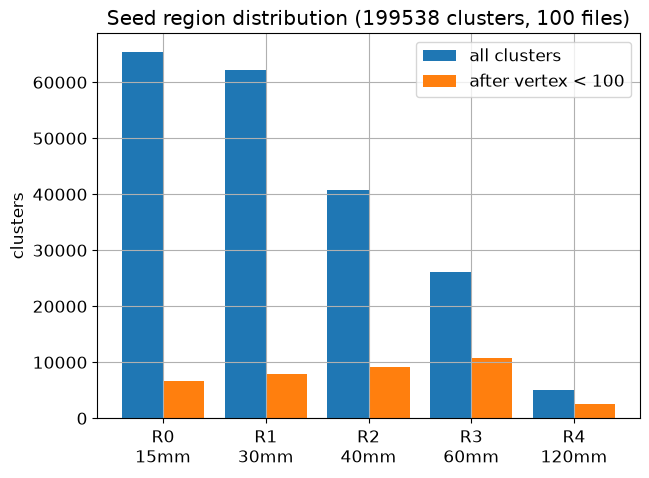

In [3]:
counts_all = np.array([(regions == r).sum() for r in range(5)])
counts_kept = np.array([((regions == r) & vertex_ok).sum() for r in range(5)])
labels = [f"R{r}\n{int(PITCH[r])}mm" for r in range(5)]

x = np.arange(5)
plt.figure()
plt.bar(x - 0.2, counts_all, width=0.4, label="all clusters")
plt.bar(x + 0.2, counts_kept, width=0.4, label="after vertex < 100")
plt.xticks(x, labels)
plt.ylabel("clusters")
plt.title(f"Seed region distribution ({len(regions)} clusters, {N_SURVEY_FILES} files)")
plt.legend()
plt.show()

## The detector face by region

Each point is one cluster's seed, coloured by its region. The concentric layout is visible: small-pitch regions sit in the centre, large-pitch regions on the outside.

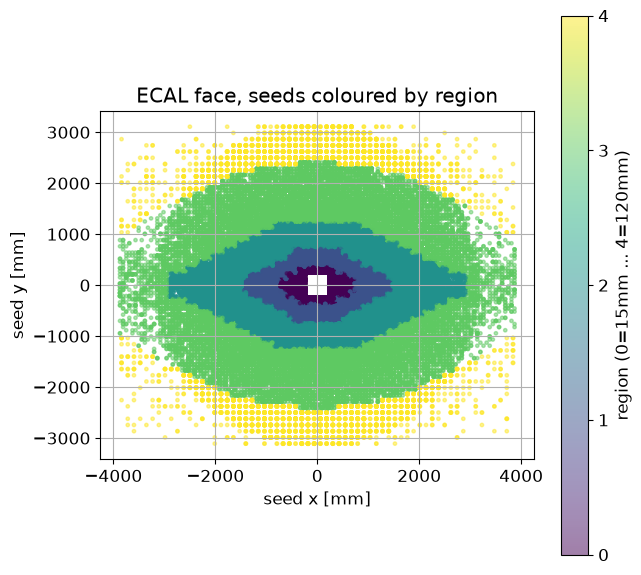

In [4]:
plt.figure(figsize=(7, 7))
sc = plt.scatter(seed_x, seed_y, c=regions, cmap="viridis", s=6, alpha=0.5)
cb = plt.colorbar(sc, ticks=range(5))
cb.set_label("region (0=15mm ... 4=120mm)")
plt.xlabel("seed x [mm]")
plt.ylabel("seed y [mm]")
plt.title("ECAL face, seeds coloured by region")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Why one region first - the window has a different physical size in each region

A fixed 3x3 window covers a very different physical area depending on the region, because cell size changes by up to 8x. Mixing regions forces one model to learn several geometries at once.

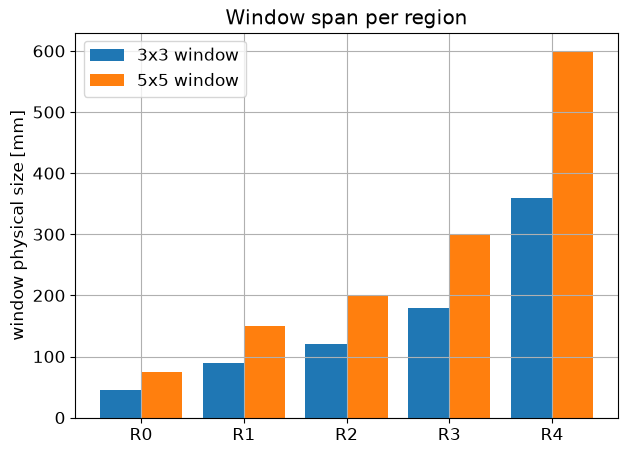

{'3x3_span_mm': [45.0, 90.0, 120.0, 180.0, 360.0],
 '5x5_span_mm': [75.0, 150.0, 200.0, 300.0, 600.0]}

In [5]:
for w in (3, 5):
    plt.bar(np.arange(5) + (0.0 if w == 3 else 0.4), w * PITCH, width=0.4, label=f"{w}x{w} window")
plt.xticks(np.arange(5) + 0.2, [f"R{r}" for r in range(5)])
plt.ylabel("window physical size [mm]")
plt.title("Window span per region")
plt.legend()
plt.show()
{"3x3_span_mm": (3 * PITCH).tolist(), "5x5_span_mm": (5 * PITCH).tolist()}

## How much data survives per region

In [6]:
best = int(np.argmax(counts_kept))
scale = len(root_files) / N_SURVEY_FILES
table = []
for r in range(5):
    table.append({
        "region": r,
        "pitch_mm": int(PITCH[r]),
        "kept_survey": int(counts_kept[r]),
        "kept_all_files_est": int(round(counts_kept[r] * scale)),
    })
{"per_region": table, "recommended_region": best,
 "reason": "most clusters surviving the vertex cut -> largest single-region training set"}

{'per_region': [{'region': 0,
   'pitch_mm': 15,
   'kept_survey': 6609,
   'kept_all_files_est': 6609},
  {'region': 1,
   'pitch_mm': 30,
   'kept_survey': 7993,
   'kept_all_files_est': 7993},
  {'region': 2,
   'pitch_mm': 40,
   'kept_survey': 9079,
   'kept_all_files_est': 9079},
  {'region': 3,
   'pitch_mm': 60,
   'kept_survey': 10692,
   'kept_all_files_est': 10692},
  {'region': 4,
   'pitch_mm': 120,
   'kept_survey': 2479,
   'kept_all_files_est': 2479}],
 'recommended_region': 3,
 'reason': 'most clusters surviving the vertex cut -> largest single-region training set'}

## Convergence - does surveying more files change the answer

The recommended region and the per-region shares are recomputed from the first 20, 40, 60, 80 and 100 files. If the shares flatten, a partial survey already gives the right picture and the recommendation is stable.

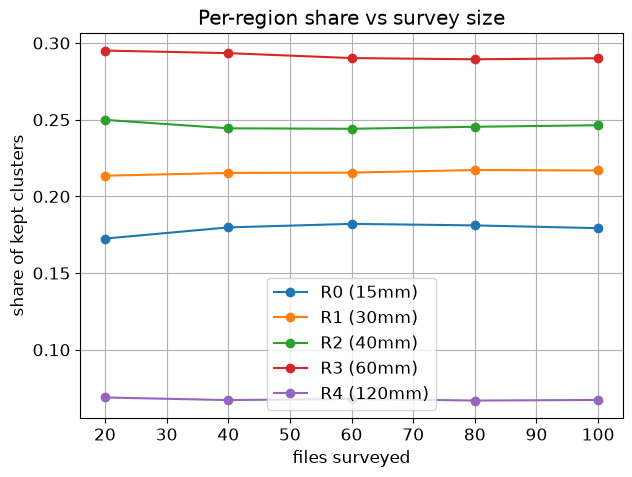

[{'files': 20,
  'kept': 7166,
  'R0_share': 0.1725,
  'R1_share': 0.2135,
  'R2_share': 0.2499,
  'R3_share': 0.2951,
  'R4_share': 0.0689,
  'best_region': 3},
 {'files': 40,
  'kept': 14668,
  'R0_share': 0.1798,
  'R1_share': 0.2153,
  'R2_share': 0.2444,
  'R3_share': 0.2934,
  'R4_share': 0.0672,
  'best_region': 3},
 {'files': 60,
  'kept': 22089,
  'R0_share': 0.1821,
  'R1_share': 0.2155,
  'R2_share': 0.2441,
  'R3_share': 0.2902,
  'R4_share': 0.068,
  'best_region': 3},
 {'files': 80,
  'kept': 29666,
  'R0_share': 0.1811,
  'R1_share': 0.2172,
  'R2_share': 0.2454,
  'R3_share': 0.2894,
  'R4_share': 0.0669,
  'best_region': 3},
 {'files': 100,
  'kept': 36852,
  'R0_share': 0.1793,
  'R1_share': 0.2169,
  'R2_share': 0.2464,
  'R3_share': 0.2901,
  'R4_share': 0.0673,
  'best_region': 3}]

In [7]:
rows = []
for n in SURVEY_STEPS:
    sub = file_index < n
    ck = np.array([((regions == r) & vertex_ok & sub).sum() for r in range(5)])
    row = {"files": n, "kept": int(ck.sum())}
    for r in range(5):
        row[f"R{r}_share"] = round(float(ck[r] / ck.sum()), 4)
    row["best_region"] = int(np.argmax(ck))
    rows.append(row)

shares = np.array([[r[f"R{k}_share"] for k in range(5)] for r in rows])
plt.figure()
for k in range(5):
    plt.plot(SURVEY_STEPS, shares[:, k], marker="o", label=f"R{k} ({int(PITCH[k])}mm)")
plt.xlabel("files surveyed")
plt.ylabel("share of kept clusters")
plt.title("Per-region share vs survey size")
plt.legend()
plt.show()
rows

## Summary

In [8]:
{
    "regions": {r: f"{int(PITCH[r])} mm" for r in range(5)},
    "identify_region_by": "cell count per module == cell pitch",
    "window_span_differs": "up to 8x across regions",
    "kept_per_region": {r: int(counts_kept[r]) for r in range(5)},
    "recommended_first_region": int(np.argmax(counts_kept)),
    "training_plan": "see notebook 04",
}

{'regions': {0: '15 mm', 1: '30 mm', 2: '40 mm', 3: '60 mm', 4: '120 mm'},
 'identify_region_by': 'cell count per module == cell pitch',
 'window_span_differs': 'up to 8x across regions',
 'kept_per_region': {0: 6609, 1: 7993, 2: 9079, 3: 10692, 4: 2479},
 'recommended_first_region': 3,
 'training_plan': 'see notebook 04'}